**Baseline modeling on merged dataset + engineered features**

## Setup

In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('ouladmerg.csv')

In [4]:
tag_feats = df.columns[:3]
module_feats = [df.columns[30]]
dataline_feats = ['date']
vle_feats = df.columns[4:24]
assess_feats = df.columns[24:30]
student_feats = df.columns[31:] 
tag_feats, student_feats, module_feats, vle_feats, assess_feats

(Index(['id_student', 'code_module', 'code_presentation'], dtype='object'),
 Index(['gender', 'region', 'highest_education', 'imd_band', 'age_band',
        'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result',
        'date_registration', 'date_unregistration'],
       dtype='object'),
 ['module_presentation_length'],
 Index(['forumng', 'homepage', 'oucontent', 'subpage', 'url', 'resource',
        'glossary', 'dataplus', 'oucollaborate', 'quiz', 'ouelluminate',
        'sharedsubpage', 'questionnaire', 'page', 'externalquiz', 'ouwiki',
        'dualpane', 'repeatactivity', 'folder', 'htmlactivity'],
       dtype='object'),
 Index(['id_assessment', 'is_banked', 'score', 'assessment_type', 'due_date',
        'weight'],
       dtype='object'))

In [5]:
def how_missing(feature, df):
    m = sum(df[feature].isnull())
    return (m, f"{(m / len(df)):.4f}")

In [6]:
print(how_missing('imd_band',df),  how_missing('date_unregistration',df))

(98792, '0.0527') (1706150, '0.9097')


For ease of processing (especially given the structure of the missing features), I am going to split into VLE and assessment dataframes. We will want to keep student data in both.

In [7]:
common_feats = list(tag_feats) + list(student_feats) + list(module_feats) + list(dataline_feats)
df_vle = df[df.id_assessment.isnull()][common_feats + list(vle_feats)]
df_assess = df[~df.id_assessment.isnull()][common_feats + list(assess_feats)]

**Aggregation strategy**

For the rest of the notebook, we will look at data aggregated at three levels: (i) for the first week; (ii) for the first three weeks; (iii) for the first third of the presentation.

*First 3 week data*

We next merge all data rows correspond to each (student, module, presentation).

In [8]:
cutoff = 22

In [9]:
df3w_vle = df_vle[df_vle.date<cutoff].drop(['date'], axis=1)
X1 = df3w_vle.drop(student_feats,axis=1).groupby(list(tag_feats)).sum()
X2y = df3w_vle[list(tag_feats)+list(student_feats)].groupby(list(tag_feats)).last()
df3w_vle = pd.concat([X1,X2y],axis=1)

In [10]:
df3w_vle.drop(['folder','repeatactivity'],axis=1,inplace=True)

## Preprocessing

Steps to be done before Pipeline:
- Add engineered features, drop some non-engineered VLE features (see `kept_features` variable below.)
- Take logarithms for the VLE features with a relatively large proportion of nonzero counts, reduce the other VLE features to binary features, and replace the `rel_submit_date` feature with a signed feature (-1 = late, 0 = on-time, 1 = early).

Steps to be done as part of Pipeline:
- Scale numeric values to be in range [0,1]
- Do one-hot encoding for categorical variables (student features)

In [11]:
kept_features = ['forumng','oucontent','url','resource','glossary','oucollaborate',
                 'quiz','questionnaire','ouwiki','dualpane',
                 'assessment_focus','content_focus',
                 'assess_freq','score','rel_submit_date','std_regularity']

### Engineered features 

Now we add engineered features.

In [12]:
vle_feats_n = list(vle_feats[:-3]) + [vle_feats[-1]]
df3w_vle['total_vle']=df3w_vle[vle_feats_n].sum(axis=1)

In [13]:
# Categorize VLE types
assessment_types = ['quiz', 'questionnaire', 'externalquiz']
content_types = ['oucontent', 'page', 'resource', 'url', 'homepage']
#collaborative_types = ['forumng', 'oucollaborate', 'ouelluminate', 'ouwiki']


df3w_vle['assessment_focus'] = df3w_vle[assessment_types].sum(axis=1) / df3w_vle.total_vle
df3w_vle['content_focus'] = df3w_vle[content_types].sum(axis=1) / df3w_vle.total_vle
#df1w_vle['collab_focus'] = df1w_vle[collaborative_types].sum(axis=1) / df1w_vle.total_vle

In [14]:
df_assess["rel_submit_date"] = df_assess["due_date"] - df_assess["date"]

In [15]:
assess_freq = df_assess[df_assess.date < cutoff].groupby(list(tag_feats)).size().rename('assess_freq')
avg_score = df_assess[df_assess.date < cutoff][list(tag_feats)+['score']].groupby(list(tag_feats)).mean()
avg_early = df_assess[df_assess.date < cutoff][list(tag_feats)+['rel_submit_date']].groupby(list(tag_feats)).mean()

In [16]:
df3w_assess = pd.concat([assess_freq,avg_score,avg_early],axis=1)
df3w_assess.sample(3)

,,,assess_freq,score,rel_submit_date
id_student,code_module,code_presentation,,,
187100,AAA,2013J,1,88.0,2.0
577096,BBB,2013J,1,90.0,2.0
589326,FFF,2013J,2,96.0,108.5


In [17]:
df3w = pd.concat([df3w_vle,df3w_assess],axis=1)

In [18]:
df3w = df3w.drop('module_presentation_length',axis=1)

In [19]:
df3w[vle_feats_n] = df3w[vle_feats_n].fillna(0)
zerofills = ['score','assess_freq','rel_submit_date',
             'assessment_focus','content_focus','total_vle']
df3w[zerofills] = df3w[zerofills].fillna(0)
df3w = df3w[~df3w.gender.isna()]
df3w = df3w[~df3w.imd_band.isna()]

In [20]:
df3w.tail(3)

,,,forumng,homepage,oucontent,subpage,url,resource,glossary,dataplus,oucollaborate,quiz,...,disability,final_result,date_registration,date_unregistration,total_vle,assessment_focus,content_focus,assess_freq,score,rel_submit_date
id_student,code_module,code_presentation,,,,,,,,,,,,,,,,,,,,,
2698535,EEE,2013J,18.0,26.0,107.0,3.0,4.0,0.0,0.0,0.0,0.0,88.0,...,N,Pass,-74.0,NaN,246.0,0.357724,0.556911,0.0,0.0,0.0
2698577,BBB,2014J,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,N,Fail,16.0,NaN,2.0,0.000000,1.000000,1.0,100.0,0.0
2698588,BBB,2014J,5.0,31.0,29.0,6.0,2.0,7.0,0.0,0.0,1.0,0.0,...,N,Distinction,4.0,NaN,81.0,0.000000,0.851852,1.0,100.0,1.0


In [21]:
# Add (overall) regularity features
def std_regularity(df, student_id_col=list(tag_feats), date_col='date'):
    return df.groupby(student_id_col)[date_col].apply(
        lambda x: x.sort_values().diff().std())    

# Lower values = more regular logins
# Higher values = more intermittent/irregular
df3w["std_regularity"] = std_regularity(df[df.date < cutoff]).fillna(0)
#df1w["days_active"] = df[df.date < cutoff].groupby(list(tag_feats)).date.nunique()


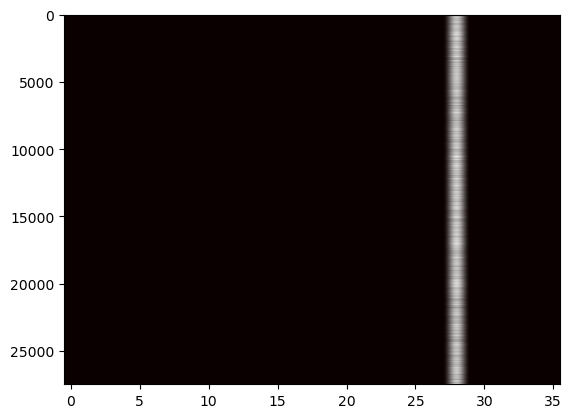

In [22]:
plt.imshow(df3w.isnull(), cmap='hot', aspect='auto')

In [23]:
engineered_feats = df3w.columns[-7:]
engineered_feats

Index(['total_vle', 'assessment_focus', 'content_focus', 'assess_freq',
       'score', 'rel_submit_date', 'std_regularity'],
      dtype='object')

### Processing for right skew

We take logarithms for the VLE features with a relatively large proportion of nonzero counts, reduce the other VLE features to binary features, and replace the `rel_submit_date` feature with a signed feature (-1 = late, 0 = on-time, 1 = early).

In [24]:
df3wl = df3w.copy()
for feat in vle_feats_n[:6] + ['total_vle', 'assess_freq', 'std_regularity']:
    df3wl[feat] = df3wl[feat].apply(lambda x:np.log(x+1))
for feat in vle_feats_n[6:]:
    df3wl[feat] = (df3wl[feat]>0).astype(int)
df3wl['rel_submit_date'] = df3wl['rel_submit_date'].apply(np.sign).astype(int)

In [25]:
student_feats, kept_features

(Index(['gender', 'region', 'highest_education', 'imd_band', 'age_band',
        'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result',
        'date_registration', 'date_unregistration'],
       dtype='object'),
 ['forumng',
  'oucontent',
  'url',
  'resource',
  'glossary',
  'oucollaborate',
  'quiz',
  'questionnaire',
  'ouwiki',
  'dualpane',
  'assessment_focus',
  'content_focus',
  'assess_freq',
  'score',
  'rel_submit_date',
  'std_regularity'])

In [61]:
X, y = df3wl[list(student_feats[:-3]) + kept_features], df3wl.final_result
X.sample(3)

,,,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,forumng,oucontent,...,quiz,questionnaire,ouwiki,dualpane,assessment_focus,content_focus,assess_freq,score,rel_submit_date,std_regularity
id_student,code_module,code_presentation,,,,,,,,,,,,,,,,,,,,,
687846,FFF,2014J,M,East Midlands Region,A Level or Equivalent,10-20,0-35,0.0,60.0,N,5.003946,4.634729,...,1,0,1,0,0.158129,0.385301,0.000000,0.0,0,1.529991
674323,BBB,2014J,F,London Region,Lower Than A Level,0-10%,0-35,0.0,60.0,N,3.218876,3.044522,...,0,0,0,0,0.000000,0.524590,0.693147,100.0,0,1.945910
582975,BBB,2013J,F,East Anglian Region,A Level or Equivalent,80-90%,0-35,0.0,60.0,N,3.610918,0.000000,...,1,0,0,0,0.010309,0.474227,0.693147,95.0,1,1.125470


## Modeling!

### Import modules and set up pipelines

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, RobustScaler

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [32]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.base import clone
from sklearn.preprocessing import LabelEncoder
from sklearn.dummy import DummyClassifier


In [30]:
X.columns

Index(['gender', 'region', 'highest_education', 'imd_band', 'age_band',
       'num_of_prev_attempts', 'studied_credits', 'disability', 'forumng',
       'oucontent', 'url', 'resource', 'glossary', 'oucollaborate', 'quiz',
       'questionnaire', 'ouwiki', 'dualpane', 'assessment_focus',
       'content_focus', 'assess_freq', 'score', 'rel_submit_date',
       'std_regularity'],
      dtype='object')

In [ ]:
model_names = ['baseline','log','rf']

scale_cols = ['num_of_prev_attempts','studied_credits','forumng','oucontent','url','resource',
              'assessment_focus','content_focus','assess_freq','score','std_regularity']
              
cat_cols = list(student_feats[:-6])+ [student_feats[-4]]

preprocessor = ColumnTransformer(
    transformers = [('scale', RobustScaler(), scale_cols),
                   ('cat_encode', OneHotEncoder(), cat_cols)],
    remainder = 'passthrough'
)

# base estimators (cloned per fit to avoid state carryover)
base_models = {
    'baseline': DummyClassifier(strategy="most_frequent"),
    'log': Pipeline([('preprocess', preprocessor), 
                     ('classify',LogisticRegression(max_iter=1000))]),
    'rf': Pipeline([('preprocess', preprocessor), 
                    ('classify',RandomForestClassifier())]),
}

### First try 

In [ ]:
le = LabelEncoder()
y_enc = le.fit_transform(y)

In [37]:

model_cv_accs = {name: None for name in model_names}

for name in model_names:
    model = clone(base_models[name])
    
    model_cv_accs[name] = cross_val_score(model,X,y_enc, cv=3)

In [38]:
model_cv_accs

{'baseline': array([0.42231685, 0.42231685, 0.42231685]),
 'log': array([0.488918  , 0.49033737, 0.49252102]),
 'rf': array([0.4993995 , 0.49688831, 0.50398515])}

Okay this wasn't very good --- can we do better?

### Second try

Let's see what happens if we reduce to two classes (Distinction + Pass vs. Fail + Withdrawn)

In [51]:
outcome_map = {'Pass':1, 'Withdrawn':0, 'Fail':0, 'Distinction':1}
y_enc = y.apply(lambda x: outcome_map[x])

In [ ]:
for name in model_names:
    model = clone(base_models[name])
    
    model_cv_accs[name] = cross_val_score(model,X,y_enc, cv=3)

In [53]:
model_cv_accs

{'baseline': array([0.52418386, 0.52418386, 0.52418386]),
 'log': array([0.68533683, 0.66786767, 0.68227972]),
 'rf': array([0.69156021, 0.69276122, 0.70597227])}

... better (but hmm ... )

### Comparison without engineered features

In [63]:
X_red = X[X.columns[:-6]]

In [64]:
scale_cols = ['num_of_prev_attempts','studied_credits','forumng','oucontent','url','resource']
              
cat_cols = list(student_feats[:-6])+ [student_feats[-4]]

preprocessor = ColumnTransformer(
    transformers = [('scale', RobustScaler(), scale_cols),
                   ('cat_encode', OneHotEncoder(), cat_cols)],
    remainder = 'passthrough'
)

# base estimators (cloned per fit to avoid state carryover)
base_models = {
    'baseline': DummyClassifier(strategy="most_frequent"),
    'log': Pipeline([('preprocess', preprocessor), 
                     ('classify',LogisticRegression(max_iter=1000))]),
    'rf': Pipeline([('preprocess', preprocessor), 
                    ('classify',RandomForestClassifier())]),
}

In [68]:
model_cv_accs = {name: None for name in model_names}

for name in model_names:
    model = clone(base_models[name])
    
    model_cv_accs[name] = cross_val_score(model,X_red,y_enc, cv=3)

model_cv_accs

{'baseline': array([0.52418386, 0.52418386, 0.52418386]),
 'log': array([0.66164428, 0.65443826, 0.6566219 ]),
 'rf': array([0.65345562, 0.65367398, 0.6535648 ])}